<a href="https://colab.research.google.com/github/sparshbansal-newton/deep-learning-labs/blob/main/Notebooks/2_Shallow_neural_networks/XOR_Simple_Demo_Part1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Notebook 1 -- The XOR Problem:** Why We Need Hidden Layers

**XOR (exclusive OR)** takes two binary inputs and outputs `1` only when the inputs are *different*:

| $x_1$ | $x_2$ | $y$ |
|:----:|:----:|:---:|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |

This tiny 4-point dataset turns out to be a big deal in the history of neural networks. A single neuron (the building block behind logistic regression / the perceptron) **cannot** learn this pattern, no matter what weights you give it. Adding just one hidden layer with a couple of neurons fixes it completely.

In this notebook, the weights are chosen by hand rather than learned through training. That lets us focus on the main idea: why a hidden layer changes what the network can represent.

A quick note on `sigmoid`: it squashes any number into the range 0 to 1, so we can read the neuron's output like a soft yes/no prediction.

In this notebook you will:
1. See *why* a single neuron is stuck drawing a straight line.
2. See how a hidden layer lets the network bend that line into a curve.
3. **Play with the numbers yourself** and watch the decision-boundary plot change, to build intuition for what each weight is actually doing.

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# The 4 XOR points and their correct labels
X = torch.tensor([[0., 0.], [0., 1.], [1., 0.], [1., 1.]])
y = torch.tensor([0., 1., 1., 0.]).unsqueeze(1)

def plot_boundary(forward_fn, title):
    # Colour the whole 2D plane by what the network predicts, so we can *see* the boundary
    xx, yy = np.meshgrid(np.arange(-0.5, 1.5, 0.01), np.arange(-0.5, 1.5, 0.01))
    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
    with torch.no_grad():
        z = forward_fn(grid).reshape(xx.shape)
    #plt.contourf(xx, yy, z, levels=20, cmap='coolwarm', alpha=0.5)
    # just two flat regions: predict-0 vs predict-1
    plt.contourf(xx, yy, z, levels=[0.0, 0.5, 1.0], cmap='coolwarm', alpha=0.4)
# one bold black line = the actual boundary
    plt.contour(xx, yy, z, levels=[0.5], colors='k', linewidths=2)
    plt.scatter(X[:, 0], X[:, 1], c=y.squeeze(), cmap='coolwarm', edgecolors='k', s=120)
    plt.title(title); plt.xlabel('x1'); plt.ylabel('x2'); plt.show()

## Part 1: A single neuron

A single neuron computes:

$$z = w_1 x_1 + w_2 x_2 + b \qquad \hat{y} = \sigma(z)$$

The boundary between "predict 0" and "predict 1" is the line where $z = 0$. That's **always a straight line** (in 2D) -- the weights and bias only control where the line sits and how it's tilted, never whether it's curved. So the real question is: *is there any straight line that puts both `(0,1)` and `(1,0)` on one side, and both `(0,0)` and `(1,1)` on the other?* Look at the 4 points on a plane and you'll see there isn't one.

Below, the weights `w = [10, 10]`, `b = -5` make the neuron behave like an **OR** gate.

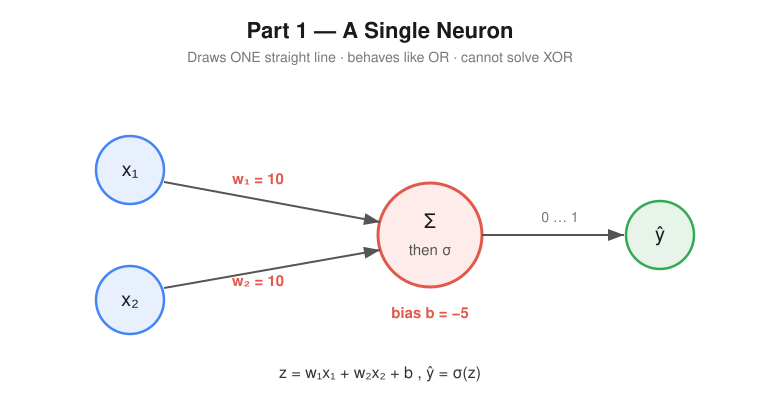

In [1]:
#@title Part 1 — Single Neuron  { display-mode: "form" }
########################################################################
#  COLAB CELL 1  —  Single Neuron diagram (Part 1)
#  Paste this whole block into a CODE cell in Colab and run it.
########################################################################

from IPython.display import SVG, display

display(SVG('''<svg viewBox="0 0 760 420" width="1000" xmlns="http://www.w3.org/2000/svg" font-family="Segoe UI, Helvetica, Arial, sans-serif">
  <defs>
    <marker id="arrow" markerWidth="10" markerHeight="10" refX="8" refY="3" orient="auto" markerUnits="strokeWidth">
      <path d="M0,0 L8,3 L0,6 Z" fill="#555"/>
    </marker>
  </defs>
  <rect x="0" y="0" width="760" height="420" fill="#ffffff"/>
  <text x="380" y="38" text-anchor="middle" font-size="22" font-weight="700" fill="#1a1a1a">Part 1 &#8212; A Single Neuron</text>
  <text x="380" y="62" text-anchor="middle" font-size="14" fill="#777">Draws ONE straight line &#183; behaves like OR &#183; cannot solve XOR</text>
  <circle cx="130" cy="170" r="34" fill="#e8f0fe" stroke="#4285f4" stroke-width="2.5"/>
  <text x="130" y="176" text-anchor="middle" font-size="20" fill="#1a1a1a">x&#8321;</text>
  <circle cx="130" cy="300" r="34" fill="#e8f0fe" stroke="#4285f4" stroke-width="2.5"/>
  <text x="130" y="306" text-anchor="middle" font-size="20" fill="#1a1a1a">x&#8322;</text>
  <circle cx="430" cy="235" r="52" fill="#fdecea" stroke="#e05a4c" stroke-width="3"/>
  <text x="430" y="228" text-anchor="middle" font-size="20" fill="#1a1a1a">&#931;</text>
  <text x="430" y="255" text-anchor="middle" font-size="15" fill="#555">then &#963;</text>
  <circle cx="660" cy="235" r="34" fill="#e6f4ea" stroke="#34a853" stroke-width="2.5"/>
  <text x="660" y="241" text-anchor="middle" font-size="20" fill="#1a1a1a">&#375;</text>
  <line x1="164" y1="182" x2="380" y2="222" stroke="#555" stroke-width="2" marker-end="url(#arrow)"/>
  <line x1="164" y1="288" x2="380" y2="250" stroke="#555" stroke-width="2" marker-end="url(#arrow)"/>
  <line x1="482" y1="235" x2="624" y2="235" stroke="#555" stroke-width="2" marker-end="url(#arrow)"/>
  <text x="258" y="184" text-anchor="middle" font-size="15" fill="#e05a4c" font-weight="600">w&#8321; = 10</text>
  <text x="258" y="286" text-anchor="middle" font-size="15" fill="#e05a4c" font-weight="600">w&#8322; = 10</text>
  <text x="430" y="318" text-anchor="middle" font-size="15" fill="#e05a4c" font-weight="600">bias b = &#8722;5</text>
  <text x="560" y="222" text-anchor="middle" font-size="14" fill="#777">0 &#8230; 1</text>
  <text x="380" y="378" text-anchor="middle" font-size="16" fill="#333">z = w&#8321;x&#8321; + w&#8322;x&#8322; + b    ,    &#375; = &#963;(z)</text>
</svg>'''))

Predictions: [0.009999999776482582, 0.9900000095367432, 0.9900000095367432, 1.0]
Target:      [0.0, 1.0, 1.0, 0.0]
Loss: 3.7160


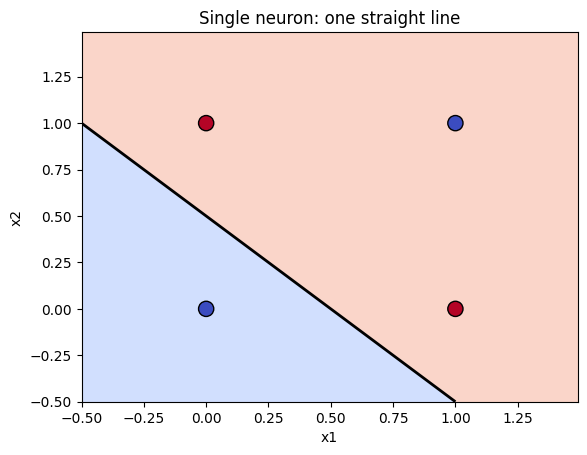

In [ ]:
class OneNeuron:
    def __init__(self, w, b):
        self.w = torch.tensor(w)
        self.b = torch.tensor(b)

    def forward(self, x):
        return torch.sigmoid(x @ self.w + self.b)

    def loss_function(self, y_pred, y_true):
        eps = 1e-7
        y_pred = torch.clamp(y_pred, eps, 1 - eps)
        return -(y_true * torch.log(y_pred) + (1 - y_true) * torch.log(1 - y_pred)).mean()

one = OneNeuron(w=[[10.], [10.]], b=[-5.])
y_pred = one.forward(X)
print(f'Predictions: {y_pred.squeeze().round(decimals=2).tolist()}')
print(f'Target:      {y.squeeze().tolist()}')
print(f'Loss: {one.loss_function(y_pred, y).item():.4f}')
plot_boundary(one.forward, 'Single neuron: one straight line')

### TODO -- play with it
Edit the values in the cell below, re-run it, and check whether your prediction matches the plot.

1. Which point is misclassified above, and why does an OR-shaped line get it wrong?
2. Change `b` from `-5` to `-15` (keep `w` the same). This now behaves like a different logic gate -- which one? Predict which point(s) will be wrong *before* you run it.
3. Try `w = [10, -10]`, `b = -5`. What logical function is this? Which points are wrong now, and why?
4. Spend two minutes trying your own combinations of `w1`, `w2`, `b`. Can you find **any** values that get all 4 points right? (You won't -- that's the whole point of this part.)

Predictions: [0.009999999776482582, 0.9900000095367432, 0.9900000095367432, 1.0]
Target:      [0.0, 1.0, 1.0, 0.0]
Loss: 3.7160


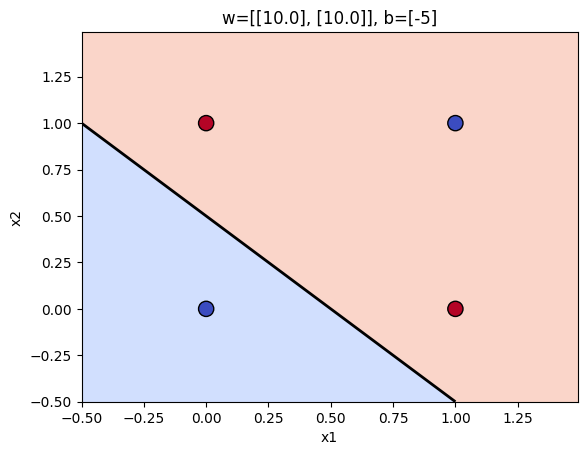

In [ ]:
# TODO: change these two values and re-run
w = [[10.], [10.]]
b = [-5]

one = OneNeuron(w, b)
y_pred = one.forward(X)
print(f'Predictions: {y_pred.squeeze().round(decimals=2).tolist()}')
print(f'Target:      {y.squeeze().tolist()}')
print(f'Loss: {one.loss_function(y_pred, y).item():.4f}')
plot_boundary(one.forward, f'w={w}, b={b}')

## Part 2: Adding a hidden layer

Now we add **one hidden layer of 2 neurons** before the output neuron:

$$\text{hidden} = \sigma(x W_1 + b_1) \qquad \hat{y} = \sigma(\text{hidden} W_2 + b_2)$$

Each hidden neuron is still just a straight-line-plus-sigmoid, exactly like Part 1 -- but now there are **two** of them, and the output neuron gets to combine their answers. That combination step is where the network gets more flexibility.

Concretely, we can make:
- hidden neuron 1 behave like **OR**
- hidden neuron 2 behave like **NAND** (opposite of AND)
- the output neuron compute **AND** of those two hidden results

**XOR = OR AND NAND**: an input should be classified as 1 when it passes the OR test and the NAND test. So instead of one straight line, the network draws two straight lines in the hidden layer and then combines them to carve out the XOR region below.

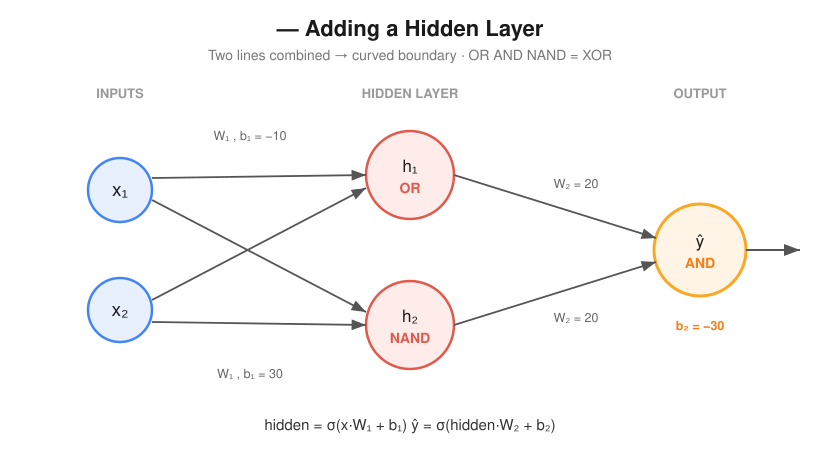

In [ ]:
#@title Part 2 — Hidden Layer Network  { display-mode: "form" }
########################################################################
#  COLAB CELL 2  —  Hidden-Layer XOR network diagram (Part 2)
#  Paste this whole block into a SECOND code cell and run it.
########################################################################

from IPython.display import SVG, display

display(SVG('''<svg viewBox="0 0 820 460" width="1000" xmlns="http://www.w3.org/2000/svg" font-family="Segoe UI, Helvetica, Arial, sans-serif">
  <defs>
    <marker id="arrow2" markerWidth="10" markerHeight="10" refX="8" refY="3" orient="auto" markerUnits="strokeWidth">
      <path d="M0,0 L8,3 L0,6 Z" fill="#555"/>
    </marker>
  </defs>
  <rect x="0" y="0" width="820" height="460" fill="#ffffff"/>
  <text x="410" y="36" text-anchor="middle" font-size="22" font-weight="700" fill="#1a1a1a"> &#8212; Adding a Hidden Layer</text>
  <text x="410" y="60" text-anchor="middle" font-size="14" fill="#777">Two lines combined &#8594; curved boundary &#183; OR AND NAND = XOR</text>
  <text x="120" y="98" text-anchor="middle" font-size="13" fill="#999" font-weight="600">INPUTS</text>
  <text x="410" y="98" text-anchor="middle" font-size="13" fill="#999" font-weight="600">HIDDEN LAYER</text>
  <text x="700" y="98" text-anchor="middle" font-size="13" fill="#999" font-weight="600">OUTPUT</text>
  <circle cx="120" cy="190" r="32" fill="#e8f0fe" stroke="#4285f4" stroke-width="2.5"/>
  <text x="120" y="196" text-anchor="middle" font-size="19" fill="#1a1a1a">x&#8321;</text>
  <circle cx="120" cy="310" r="32" fill="#e8f0fe" stroke="#4285f4" stroke-width="2.5"/>
  <text x="120" y="316" text-anchor="middle" font-size="19" fill="#1a1a1a">x&#8322;</text>
  <circle cx="410" cy="175" r="44" fill="#fdecea" stroke="#e05a4c" stroke-width="2.5"/>
  <text x="410" y="172" text-anchor="middle" font-size="17" fill="#1a1a1a">h&#8321;</text>
  <text x="410" y="193" text-anchor="middle" font-size="14" fill="#e05a4c" font-weight="700">OR</text>
  <circle cx="410" cy="325" r="44" fill="#fdecea" stroke="#e05a4c" stroke-width="2.5"/>
  <text x="410" y="322" text-anchor="middle" font-size="17" fill="#1a1a1a">h&#8322;</text>
  <text x="410" y="343" text-anchor="middle" font-size="14" fill="#e05a4c" font-weight="700">NAND</text>
  <circle cx="700" cy="250" r="46" fill="#fff4e5" stroke="#f9a825" stroke-width="3"/>
  <text x="700" y="247" text-anchor="middle" font-size="17" fill="#1a1a1a">&#375;</text>
  <text x="700" y="268" text-anchor="middle" font-size="14" fill="#f57f17" font-weight="700">AND</text>
  <line x1="152" y1="178" x2="366" y2="175" stroke="#555" stroke-width="1.8" marker-end="url(#arrow2)"/>
  <line x1="152" y1="200" x2="366" y2="312" stroke="#555" stroke-width="1.8" marker-end="url(#arrow2)"/>
  <line x1="152" y1="300" x2="366" y2="188" stroke="#555" stroke-width="1.8" marker-end="url(#arrow2)"/>
  <line x1="152" y1="322" x2="366" y2="325" stroke="#555" stroke-width="1.8" marker-end="url(#arrow2)"/>
  <line x1="454" y1="175" x2="656" y2="238" stroke="#555" stroke-width="1.8" marker-end="url(#arrow2)"/>
  <line x1="454" y1="325" x2="656" y2="262" stroke="#555" stroke-width="1.8" marker-end="url(#arrow2)"/>
  <line x1="746" y1="250" x2="800" y2="250" stroke="#555" stroke-width="2" marker-end="url(#arrow2)"/>
  <text x="250" y="140" text-anchor="middle" font-size="12.5" fill="#666">W&#8321; , b&#8321; = &#8722;10</text>
  <text x="250" y="378" text-anchor="middle" font-size="12.5" fill="#666">W&#8321; , b&#8321; = 30</text>
  <text x="576" y="188" text-anchor="middle" font-size="12.5" fill="#666">W&#8322; = 20</text>
  <text x="576" y="322" text-anchor="middle" font-size="12.5" fill="#666">W&#8322; = 20</text>
  <text x="700" y="330" text-anchor="middle" font-size="12.5" fill="#f57f17" font-weight="600">b&#8322; = &#8722;30</text>
  <text x="410" y="430" text-anchor="middle" font-size="15" fill="#333">hidden = &#963;(x&#183;W&#8321; + b&#8321;)        &#375; = &#963;(hidden&#183;W&#8322; + b&#8322;)</text>
</svg>'''))


Predictions: [0.0, 1.0, 1.0, 0.0]
Target:      [0.0, 1.0, 1.0, 0.0]
Loss: 0.0000


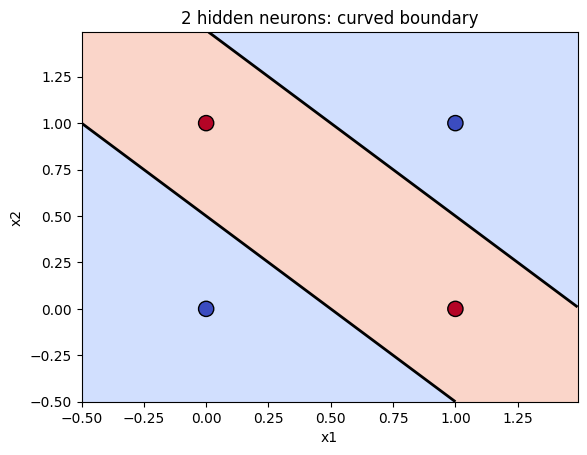

In [ ]:
class TwoNeuronXOR:
    def __init__(self, W1, b1, W2, b2):
        self.W1 = torch.tensor(W1)
        self.b1 = torch.tensor(b1)
        self.W2 = torch.tensor(W2)
        self.b2 = torch.tensor(b2)

    def forward(self, x):
        hidden = torch.sigmoid(x @ self.W1 + self.b1)   # non-linearity bends the space here
        return torch.sigmoid(hidden @ self.W2 + self.b2)

    def loss_function(self, y_pred, y_true):
        eps = 1e-7
        y_pred = torch.clamp(y_pred, eps, 1 - eps)
        return -(y_true * torch.log(y_pred) + (1 - y_true) * torch.log(1 - y_pred)).mean()

two = TwoNeuronXOR(
    W1=[[20., -20.], [20., -20.]],   # column 1 -> OR, column 2 -> NAND
    b1=[-10., 30.],
    W2=[[20.], [20.]],                # combine hidden neurons -> AND
    b2=[-30.],
)
y_pred = two.forward(X)
print(f'Predictions: {y_pred.squeeze().round(decimals=2).tolist()}')
print(f'Target:      {y.squeeze().tolist()}')
print(f'Loss: {two.loss_function(y_pred, y).item():.4f}')
plot_boundary(two.forward, '2 hidden neurons: curved boundary')

### TODO -- play with it
Nothing here was trained -- every number was picked by hand. Change the values below, re-run, and see if the plot matches your prediction.

1. Change the second value of `b1` from `30` to `10`. This shifts the NAND neuron's threshold. Predict which point(s) will flip before running.
2. Change `W2` from `[[20.], [20.]]` to `[[20.], [-20.]]`, flipping the sign of the second hidden neuron's contribution. What happens to the boundary?
3. Make `W1`'s two columns identical, e.g. `[[20., 20.], [20., 20.]]`, so both hidden neurons compute the exact same thing. Predict: does having "2 neurons" still help if they're identical? Check the plot.
4. Multiply every one of `W1`, `b1`, `W2`, `b2` by `0.1` (small weights) and then by `5` (large weights). What happens to the sharpness of the boundary as the numbers get bigger or smaller?

Predictions: [0.0, 1.0, 1.0, 0.0]
Target:      [0.0, 1.0, 1.0, 0.0]
Loss: 0.0000


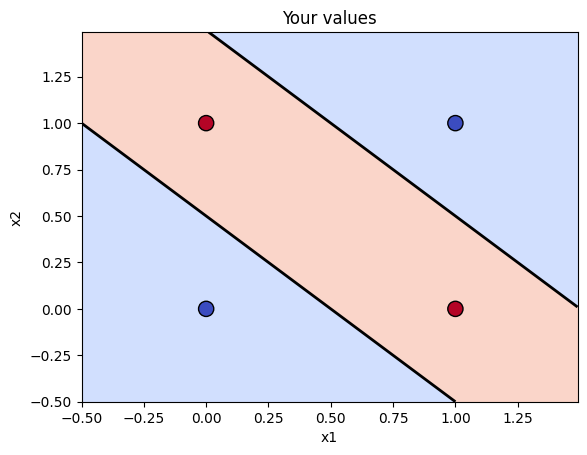

In [ ]:
# TODO: change these four values and re-run
W1 = [[20., -20.], [20., -20.]]
b1 = [-10., 30.]
W2 = [[20.], [20.]]
b2 = [-30.]

two = TwoNeuronXOR(W1, b1, W2, b2)
y_pred = two.forward(X)
print(f'Predictions: {y_pred.squeeze().round(decimals=2).tolist()}')
print(f'Target:      {y.squeeze().tolist()}')
print(f'Loss: {two.loss_function(y_pred, y).item():.4f}')
plot_boundary(two.forward, 'Your values')

## Takeaway

- A single neuron can only ever separate points with a straight line, so it can never solve XOR -- no choice of weights works.
- Adding a hidden layer gives the network more than one line to work with, and combining those lines through another neuron produces a curved boundary.
- This is a tiny example of a much bigger idea: with enough hidden neurons, a network can bend its decision boundary to fit almost any pattern you throw at it.